# Phase 3B: Calibration Sensitivity Analysis

**Focus**: Only test configurations where preprocessing provided significant improvements (Phase 5 results)

**Goal**: Understand minimum calibration data needed for each high-performing configuration

**Configurations to test** (Phase 5 delta > 0.3):
- pump 6_dB id_04 (delta: +0.8145) - max: 702 clips
- pump 0_dB id_04 (delta: +0.7828) - max: 702 clips
- pump -6_dB id_04 (delta: +0.6510) - max: 702 clips
- fan 6_dB id_04 (delta: +0.5815) - max: 1033 clips
- fan 6_dB id_06 (delta: +0.5371) - max: 970 clips

**Calibration sizes**: [3, 10, 50, 100, 500] + actual max per configuration

**Note**: random_state starts from 42 to match Phase 4-5

## Setup

In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import pickle
from pathlib import Path
import pandas as pd

sys.path.insert(0, 'C:/Users/Letizia/Documents/sound-anomaly-detection/src')
from calibration_sensitivity import CalibrationSensitivityAnalysis
from audio_loader import AudioLoader

print('✓ Imports successful')

results_dir = Path('C:/Users/Letizia/Documents/sound-anomaly-detection/results')
results_dir.mkdir(exist_ok=True)

# High-impact configurations from Phase 5 (delta > 0.3)
high_impact_configs = [
    ('pump', '6_dB', 'id_04', 0.7532),
    ('pump', '0_dB', 'id_04', 0.7418),
    ('pump', '-6_dB', 'id_04', 0.5729),
    ('fan', '6_dB', 'id_06', 0.5571),
    ('slider', '6_dB', 'id_04', 0.4616)
]

print(f'\nTesting {len(high_impact_configs)} high-impact configurations:')
for machine, cond, test_id, delta in high_impact_configs:
    print(f'  {machine:6s} {cond:6s} {test_id}: delta = +{delta:.4f}')

✓ Imports successful

Testing 5 high-impact configurations:
  pump   6_dB   id_04: delta = +0.7532
  pump   0_dB   id_04: delta = +0.7418
  pump   -6_dB  id_04: delta = +0.5729
  fan    6_dB   id_06: delta = +0.5571
  slider 6_dB   id_04: delta = +0.4616


## Run Calibration Sensitivity on High-Impact Configurations

In [2]:
all_results = {}
summary_rows = []

for machine_type, condition, test_id, expected_delta in high_impact_configs:
    condition_short = condition.replace('_dB', 'dB')
    config_name = f'{machine_type}_{condition}_{test_id}'
    
    print(f'\n{"-"*70}')
    print(f'Config: {config_name} (expected delta: +{expected_delta:.4f})')
    print(f'{"-"*70}')
    
    try:
        # Load training data
        X_train = np.load(results_dir / f'X_train_{condition_short}_{machine_type}.npy')
        with open(results_dir / f'machine_ids_train_{condition_short}_{machine_type}.pkl', 'rb') as f:
            machine_ids_train = pickle.load(f)
        
        # Load test data
        X_test = np.load(results_dir / f'X_test_{condition_short}_{machine_type}_{test_id}.npy')
        y_test = np.load(results_dir / f'y_test_{condition_short}_{machine_type}_{test_id}.npy')
        
        # Load test machine normal clips for calibration
        loader = AudioLoader(data_root='C:/Users/Letizia/Documents/sound-anomaly-detection/data', sr=16000, n_mfcc=13, machine_type=machine_type)
        data_test = loader.load_condition_dataset(
            condition=condition,
            machine_ids=[test_id],
            aggregate_method='mean_std'
        )
        test_normal_features = np.array(data_test['machine_ids'][test_id]['normal']['features'])
        max_clips = test_normal_features.shape[0]
        
        print(f'Data loaded: X_train {X_train.shape}, X_test {X_test.shape}')
        print(f'Test normal clips available: {max_clips}')
        
        # Run calibration sensitivity with automatic size detection
        # This will use [10, 50, 100, 500, max_clips]
        analyzer = CalibrationSensitivityAnalysis()
        results = analyzer.run_analysis(
            X_train, machine_ids_train,
            X_test, y_test,
            test_normal_features,
            test_id,
            calibration_sizes=None,  # Auto: [10, 50, 100, 500, max_clips]
            n_seeds=10,  # Match Phase 4-5
            use_modified=True  # Use preprocessed features
        )
        
        # Store results
        all_results[config_name] = results
        
        # Add to summary
        for size, auc_mean, auc_std in zip(results['sizes'], results['auc_means'], results['auc_stds']):
            summary_rows.append({
                'Machine': machine_type,
                'Condition': condition,
                'Test ID': test_id,
                'Calib Size': size,
                'AUC Mean': auc_mean,
                'AUC Std': auc_std
            })
        
        print(f'✓ Complete')
    
    except FileNotFoundError as e:
        print(f'✗ Missing files: {str(e)[:50]}')
    except Exception as e:
        print(f'✗ Error: {str(e)[:50]}')

print(f'Configurations analyzed: {len(all_results)}')


----------------------------------------------------------------------
Config: pump_6_dB_id_04 (expected delta: +0.7532)
----------------------------------------------------------------------
✓ AudioLoader initialized
  - Data root: C:\Users\Letizia\Documents\sound-anomaly-detection\data
  - Machine type: pump
  - Sampling rate: 16000 Hz
  - MFCC coefficients: 13

Loading condition: 6_dB (pump)
  Loading id_04 normal sounds... ✓ 702 clips
  Loading id_04 abnormal sounds... ✓ 100 clips
Data loaded: X_train (2011, 26), X_test (802, 26)
Test normal clips available: 702

CALIBRATION SENSITIVITY ANALYSIS: id_04
Available normal clips for calibration: 702
Testing calibration sizes: [3, 10, 50, 100, 500, 702]
Seeds per size: 10

  Calibration size: 3
✓ PreprocessingModifications initialized

FITTING MODIFICATION 1: Per-Machine-ID Normalization
  id_00: computed mean from 1006 samples
    Sample mean values: [-371.94388     93.581985    -7.276694    10.725988    -3.6221194]
  id_02: computed 

## Results Summary

In [3]:
if summary_rows:
    summary_df = pd.DataFrame(summary_rows)
    print('\nCalibration Sensitivity Results (modified features):')
    print(summary_df.to_string(index=False))
    
    # Save summary
    summary_df.to_csv(results_dir / 'phase3b_calibration_sensitivity_results.csv', index=False)
    with open(results_dir / 'phase3b_calibration_sensitivity_results.pkl', 'wb') as f:
        pickle.dump(all_results, f)
    
    print(f'\n✓ Saved: phase3b_calibration_sensitivity_results.csv')
    print(f'✓ Saved: phase3b_calibration_sensitivity_results.pkl')


Calibration Sensitivity Results (modified features):
Machine Condition Test ID  Calib Size  AUC Mean  AUC Std
   pump      6_dB   id_04           3  0.903704 0.039279
   pump      6_dB   id_04          10  0.935534 0.014649
   pump      6_dB   id_04          50  0.941755 0.009696
   pump      6_dB   id_04         100  0.943812 0.009413
   pump      6_dB   id_04         500  0.943437 0.008716
   pump      6_dB   id_04         702  0.943678 0.008682
   pump      0_dB   id_04           3  0.868947 0.016861
   pump      0_dB   id_04          10  0.893446 0.015987
   pump      0_dB   id_04          50  0.898726 0.013215
   pump      0_dB   id_04         100  0.899803 0.012387
   pump      0_dB   id_04         500  0.901124 0.010718
   pump      0_dB   id_04         702  0.900944 0.010463
   pump     -6_dB   id_04           3  0.775315 0.089898
   pump     -6_dB   id_04          10  0.817434 0.034132
   pump     -6_dB   id_04          50  0.831718 0.013849
   pump     -6_dB   id_04         

## Visualization: AUC vs. Calibration Size per Configuration

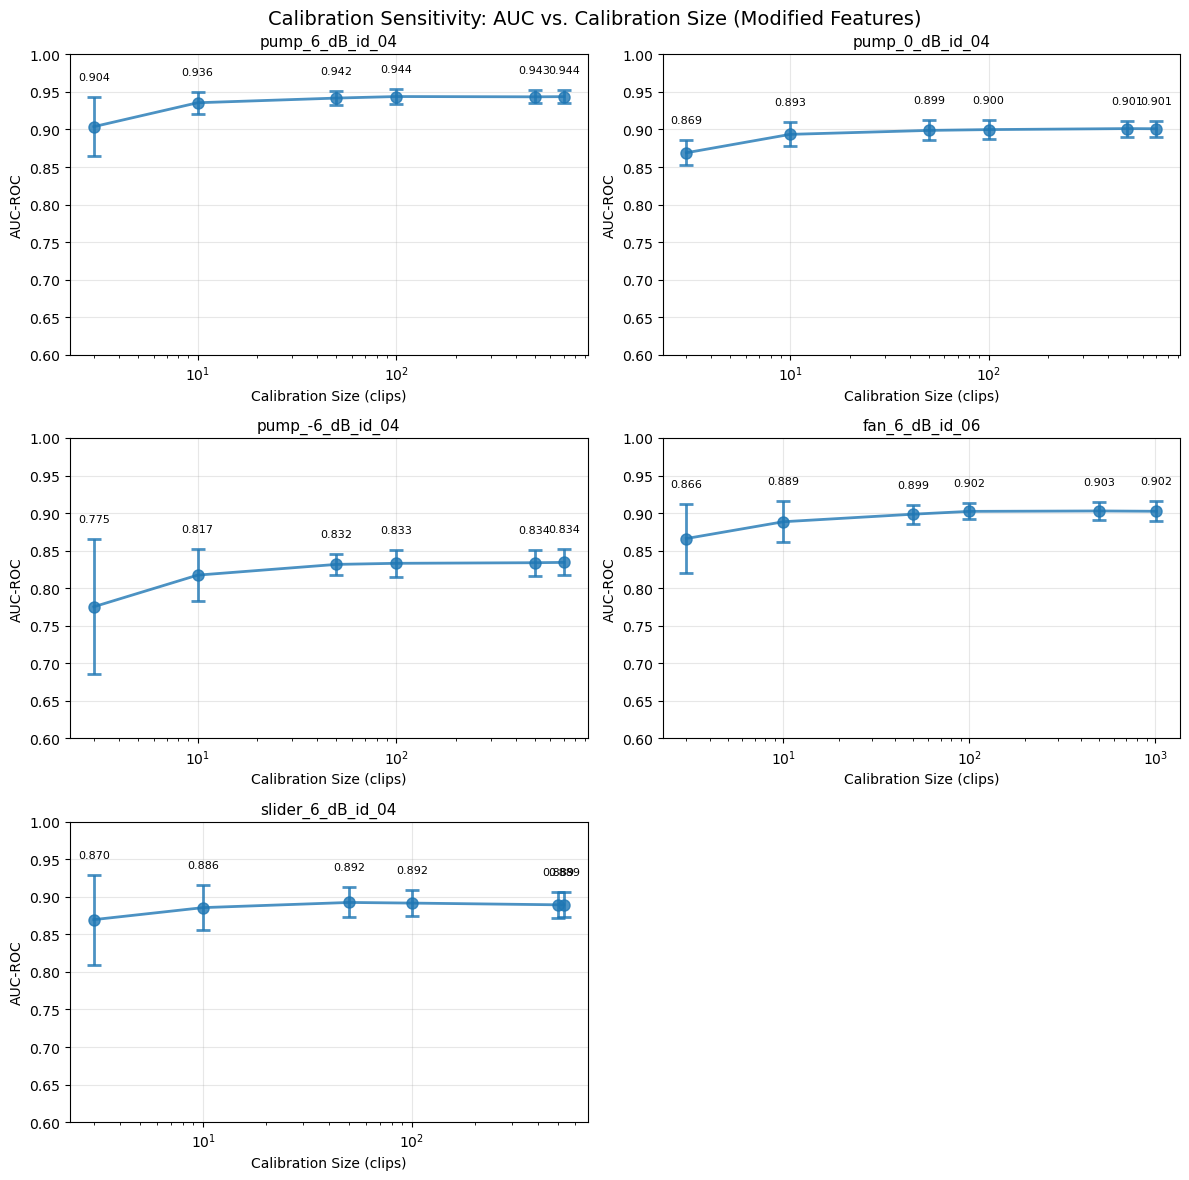

✓ Saved: phase3b_calibration_sensitivity.png


In [21]:
if all_results:
    fig, axes = plt.subplots(3, 2, figsize=(12, 12))
    fig.suptitle('Calibration Sensitivity: AUC vs. Calibration Size (Modified Features)', fontsize=14)
    axes = axes.flatten()
    
    for idx, (config_name, results) in enumerate(all_results.items()):
        ax = axes[idx]
        
        sizes = results['sizes']
        auc_means = results['auc_means']
        auc_stds = results['auc_stds']
        
        # Plot with error bars
        ax.errorbar(
            sizes, auc_means, yerr=auc_stds,
            marker='o', markersize=8, linewidth=2,
            capsize=5, capthick=2, alpha=0.8
        )
        
        # Add value labels
        for size, auc, std in zip(sizes, auc_means, auc_stds):
            ax.text(size, auc + std + 0.02, f'{auc:.3f}', 
                   ha='center', va='bottom', fontsize=8)
        
        ax.set_xlabel('Calibration Size (clips)', fontsize=10)
        ax.set_ylabel('AUC-ROC', fontsize=10)
        ax.set_title(config_name, fontsize=11)
        ax.set_xscale('log')
        ax.set_ylim([0.6, 1.0])
        ax.grid(True, alpha=0.3)
    
    # Remove empty subplots
    for idx in range(len(all_results), len(axes)):
        fig.delaxes(axes[idx])
    
    plt.tight_layout()
    plt.savefig(results_dir / 'phase3b_calibration_sensitivity.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f'✓ Saved: phase3b_calibration_sensitivity.png')

## Key Insights

In [5]:
print(f'\n{"="*70}')
print('KEY INSIGHTS FROM CALIBRATION SENSITIVITY')
print(f'{"="*70}')

for config_name, results in all_results.items():
    print(f'\n{config_name}:')
    sizes = results['sizes']
    auc_means = results['auc_means']
    
    # Show progression
    for size, auc in zip(sizes, auc_means):
        max_size_label = f'(max available)' if size == results['max_available'] else ''
        print(f'  {size:5d} clips: {auc:.4f} {max_size_label}')
    
    # Find practical saturation (90% of max)
    max_auc = max(auc_means)
    threshold_90 = max_auc * 0.90
    practical_sizes = [s for s, auc in zip(sizes, auc_means) if auc >= threshold_90]
    
    if practical_sizes:
        practical_size = practical_sizes[0]
        practical_auc = auc_means[sizes.index(practical_size)]
        print(f'  → 90% saturation at {practical_size} clips ({practical_auc:.4f} AUC)')
    
    # Total improvement
    improvement = auc_means[-1] - auc_means[0]
    print(f'  → Total improvement: {improvement:+.4f}')


KEY INSIGHTS FROM CALIBRATION SENSITIVITY

pump_6_dB_id_04:
      3 clips: 0.9037 
     10 clips: 0.9355 
     50 clips: 0.9418 
    100 clips: 0.9438 
    500 clips: 0.9434 
    702 clips: 0.9437 (max available)
  → 90% saturation at 3 clips (0.9037 AUC)
  → Total improvement: +0.0400

pump_0_dB_id_04:
      3 clips: 0.8689 
     10 clips: 0.8934 
     50 clips: 0.8987 
    100 clips: 0.8998 
    500 clips: 0.9011 
    702 clips: 0.9009 (max available)
  → 90% saturation at 3 clips (0.8689 AUC)
  → Total improvement: +0.0320

pump_-6_dB_id_04:
      3 clips: 0.7753 
     10 clips: 0.8174 
     50 clips: 0.8317 
    100 clips: 0.8332 
    500 clips: 0.8340 
    702 clips: 0.8344 (max available)
  → 90% saturation at 3 clips (0.7753 AUC)
  → Total improvement: +0.0591

fan_6_dB_id_06:
      3 clips: 0.8661 
     10 clips: 0.8885 
     50 clips: 0.8986 
    100 clips: 0.9023 
    500 clips: 0.9029 
   1015 clips: 0.9024 (max available)
  → 90% saturation at 3 clips (0.8661 AUC)
  → Tota

## Graph: Publication Quality

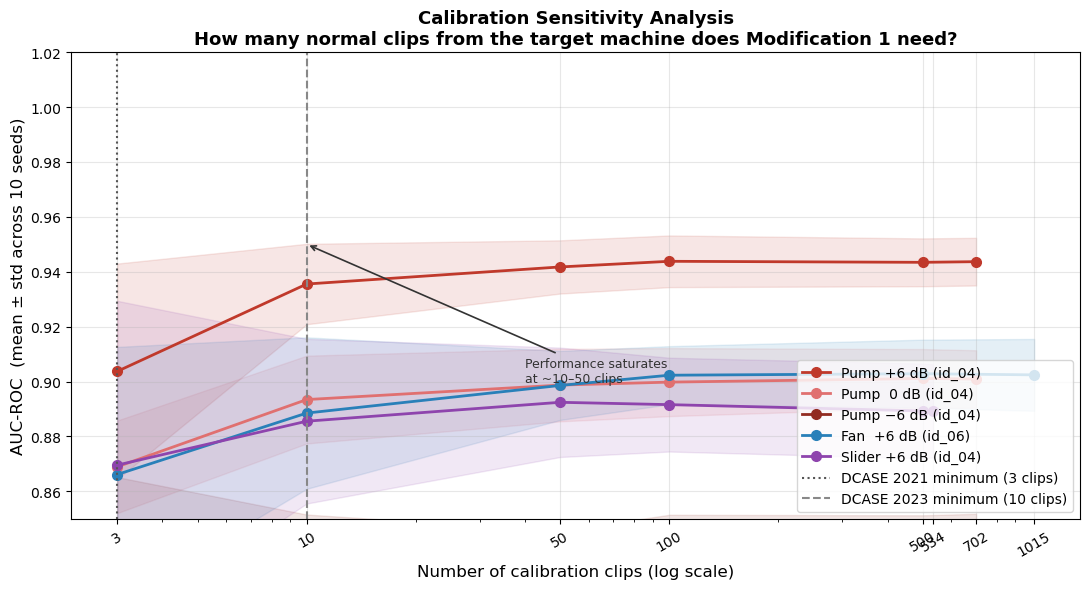

✓ Saved: C:\Users\Letizia\Documents\sound-anomaly-detection\results\figure_calibration_sensitivity_publication.png


In [6]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# Config display names
config_labels = {
    'pump_6_dB_id_04':   ('Pump +6 dB (id_04)',  '#C0392B'),
    'pump_0_dB_id_04':   ('Pump  0 dB (id_04)',  '#E07070'),
    'pump_-6_dB_id_04':  ('Pump −6 dB (id_04)',  '#922B21'),
    'fan_6_dB_id_06':    ('Fan  +6 dB (id_06)',  '#2980B9'),
    'slider_6_dB_id_04': ('Slider +6 dB (id_04)', '#8E44AD'),
}

fig, ax = plt.subplots(figsize=(11, 6))

for config_name, results in all_results.items():
    label_text, color = config_labels.get(config_name, (config_name, 'gray'))
    sizes = results['sizes']
    means = np.array(results['auc_means'])
    stds  = np.array(results['auc_stds'])

    ax.plot(sizes, means, marker='o', markersize=7, linewidth=2,
            color=color, label=label_text)
    ax.fill_between(sizes, means - stds, means + stds,
                    color=color, alpha=0.12)

# DCASE reference lines
ax.axvline(x=3, color='#555555', linestyle=':', linewidth=1.5,
           label='DCASE 2021 minimum (3 clips)')
ax.axvline(x=10, color='#888888', linestyle='--', linewidth=1.5,
           label='DCASE 2023 minimum (10 clips)')

ax.set_xscale('log')
ax.set_xlabel('Number of calibration clips (log scale)', fontsize=12)
ax.set_ylabel('AUC-ROC  (mean ± std across 10 seeds)', fontsize=12)
ax.set_title(
    'Calibration Sensitivity Analysis\n'
    'How many normal clips from the target machine does Modification 1 need?',
    fontsize=13, fontweight='bold'
)
ax.set_ylim([0.85, 1.02])

# Set x ticks from actual data
all_sizes = sorted(set(s for r in all_results.values() for s in r['sizes']))
ax.set_xticks(all_sizes)
ax.get_xaxis().set_major_formatter(ticker.ScalarFormatter())
ax.tick_params(axis='x', rotation=30)
ax.grid(alpha=0.3)
ax.legend(fontsize=10, loc='lower right')

ax.annotate(
    'Performance saturates\nat ~10–50 clips',
    xy=(10, 0.950), xytext=(40, 0.900),
    fontsize=9, color='#333333',
    arrowprops=dict(arrowstyle='->', color='#333333', lw=1.2)
)

plt.tight_layout()
fig_path = results_dir / 'figure_calibration_sensitivity_publication.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'✓ Saved: {fig_path}')